# Volatility-Aware Risk Controls

Test volatility-targeted position sizing and volatility-adjusted trailing stops.

## Code Steps

1. Load extended close prices.
2. Start with QQQ 20-day momentum long/cash.
3. Add volatility-targeted position sizing.
4. Add volatility-adjusted trailing stops.
5. Compare each variant by Sharpe, return, volatility, and max drawdown.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.research.backtest import backtest_weights, format_percent_table
from src.research.strategies import apply_trailing_stop, buy_and_hold_weights, long_cash_momentum_weights, volatility_target_weights

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CLOSE_PATH = PROCESSED_DIR / "extended_close_prices.csv"
DAILY_OUTPUT_PATH = PROCESSED_DIR / "risk_control_daily.csv"
RESULTS_OUTPUT_PATH = PROCESSED_DIR / "risk_control_results.csv"

In [2]:
close = pd.read_csv(CLOSE_PATH, index_col="Date", parse_dates=True)
close = close[["SPY", "QQQ"]].dropna()

close.tail()

,SPY,QQQ
Date,,
2026-06-29,741.000000,724.080017
2026-06-30,746.770020,736.400024
2026-07-01,745.760010,725.169983
2026-07-02,744.780029,712.599976
2026-07-06,751.669983,723.369995


In [3]:
base_weights = long_cash_momentum_weights(close, "QQQ", 20)

strategy_weights = {
    "buy_hold_QQQ": buy_and_hold_weights(close, "QQQ"),
    "QQQ_momentum_20d": base_weights,
}

for target_vol in [0.10, 0.12, 0.15]:
    strategy_weights[f"QQQ_momentum_20d_vol_target_{int(target_vol * 100)}"] = volatility_target_weights(
        close,
        base_weights,
        target_volatility=target_vol,
        volatility_window=20,
        max_leverage=1.0,
    )

for multiplier in [2.0, 3.0, 4.0]:
    strategy_weights[f"QQQ_momentum_20d_trailing_{multiplier:.0f}x_vol"] = apply_trailing_stop(
        close,
        base_weights,
        asset="QQQ",
        volatility_window=20,
        volatility_multiplier=multiplier,
    )

len(strategy_weights)

8

In [4]:
daily_frames = []
metric_rows = []

for name, weights in strategy_weights.items():
    daily, metrics = backtest_weights(close, weights, name=name, transaction_cost_bps=1.0)
    daily_frames.append(daily)
    metric_rows.append(metrics)

risk_daily = pd.concat(daily_frames, ignore_index=True)
risk_results = pd.DataFrame(metric_rows).sort_values("sharpe", ascending=False)

risk_results

,strategy,rows,total_return,annual_return,annual_volatility,sharpe,max_drawdown,calmar,positive_day_rate,avg_exposure,annual_turnover,total_transaction_cost
4,QQQ_momentum_20d_vol_target_15,2892,3.290859,0.135319,0.121791,1.103304,-0.177133,0.763939,0.380014,0.628455,20.312786,0.023311
3,QQQ_momentum_20d_vol_target_12,2892,2.766923,0.122509,0.111087,1.096176,-0.163000,0.751586,0.380014,0.585107,20.160975,0.023137
2,QQQ_momentum_20d_vol_target_10,2892,2.316679,0.110127,0.100812,1.087007,-0.149026,0.738975,0.380014,0.535230,19.631210,0.022529
1,QQQ_momentum_20d,2892,3.863269,0.147775,0.135961,1.082023,-0.199521,0.740649,0.380014,0.670470,20.041494,0.023000
7,QQQ_momentum_20d_trailing_4x_vol,2892,3.732958,0.145062,0.135179,1.069967,-0.196284,0.739039,0.376902,0.666321,21.784232,0.025000
6,QQQ_momentum_20d_trailing_3x_vol,2892,2.911346,0.126195,0.133026,0.960165,-0.197863,0.637789,0.368949,0.654910,27.012448,0.031000
5,QQQ_momentum_20d_trailing_2x_vol,2892,2.814483,0.123737,0.131712,0.951840,-0.237029,0.522030,0.361687,0.638658,34.331950,0.039400
0,buy_hold_QQQ,2892,6.649756,0.193984,0.219449,0.918133,-0.351187,0.552365,0.561203,1.000000,0.000000,0.000000


In [5]:
percent_cols = [
    "total_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
    "calmar",
    "avg_exposure",
    "annual_turnover",
    "total_transaction_cost",
    "positive_day_rate",
]

format_percent_table(risk_results, percent_cols)[[
    "strategy",
    "sharpe",
    "total_return",
    "annual_return",
    "annual_volatility",
    "max_drawdown",
    "avg_exposure",
    "annual_turnover",
]]

,strategy,sharpe,total_return,annual_return,annual_volatility,max_drawdown,avg_exposure,annual_turnover
4,QQQ_momentum_20d_vol_target_15,1.103304,329.09%,13.53%,12.18%,-17.71%,62.85%,2031.28%
3,QQQ_momentum_20d_vol_target_12,1.096176,276.69%,12.25%,11.11%,-16.30%,58.51%,2016.10%
2,QQQ_momentum_20d_vol_target_10,1.087007,231.67%,11.01%,10.08%,-14.90%,53.52%,1963.12%
1,QQQ_momentum_20d,1.082023,386.33%,14.78%,13.60%,-19.95%,67.05%,2004.15%
7,QQQ_momentum_20d_trailing_4x_vol,1.069967,373.30%,14.51%,13.52%,-19.63%,66.63%,2178.42%
6,QQQ_momentum_20d_trailing_3x_vol,0.960165,291.13%,12.62%,13.30%,-19.79%,65.49%,2701.24%
5,QQQ_momentum_20d_trailing_2x_vol,0.951840,281.45%,12.37%,13.17%,-23.70%,63.87%,3433.20%
0,buy_hold_QQQ,0.918133,664.98%,19.40%,21.94%,-35.12%,100.00%,0.00%


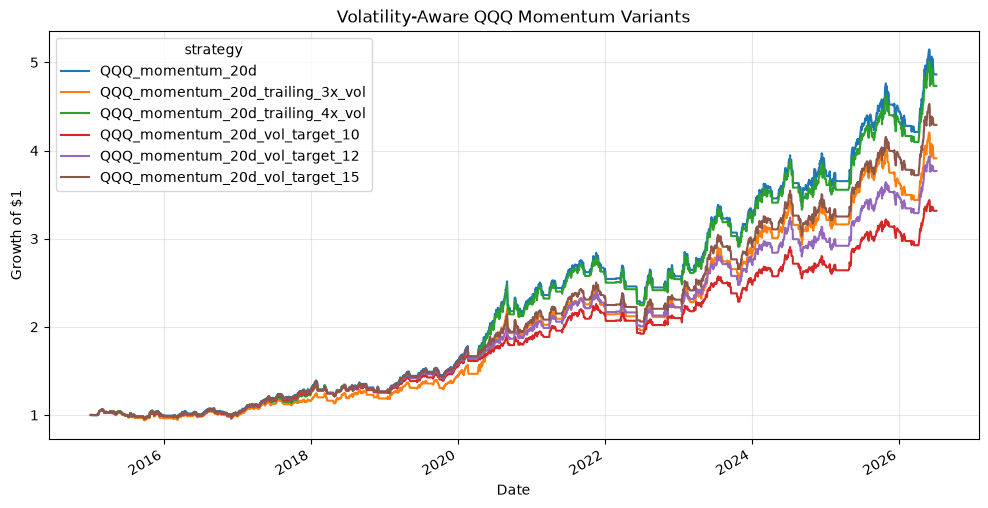

In [6]:
top_strategies = risk_results.head(6)["strategy"].tolist()
plot_frame = risk_daily[risk_daily["strategy"].isin(top_strategies)]
plot_frame = plot_frame.pivot(index="Date", columns="strategy", values="equity_curve")

ax = plot_frame.plot(figsize=(12, 6))
ax.set_title("Volatility-Aware QQQ Momentum Variants")
ax.set_ylabel("Growth of $1")
ax.grid(True, alpha=0.3)
plt.show()

In [7]:
risk_daily.to_csv(DAILY_OUTPUT_PATH, index=False)
risk_results.to_csv(RESULTS_OUTPUT_PATH, index=False)

DAILY_OUTPUT_PATH, RESULTS_OUTPUT_PATH

(WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/risk_control_daily.csv'),
 WindowsPath('C:/Users/nqmin/Documents/Project/Predictions/data/processed/risk_control_results.csv'))